# ⚽ TASK 1. 데이터 출처 설명 및 데이터 불러오기

---

## 1.1 데이터 선정 이유 및 도메인 개요
평소 축구 경기를 시청하며 단순히 승패를 확인하는 것을 넘어, 선수의 움직임 하나하나와 전술적 흐름에 깊은 관심을 가져왔습니다. "왜 저 선수는 저 타이밍에 저 공간으로 패스를 보냈을까?"라는 의문은 제가 축구 데이터를 분석하게 된 가장 큰 동기입니다.

현대 축구에서 승패는 개별 선수의 기량을 넘어, **보이지 않는 공간을 창출하고 유기적인 팀 패턴을 만드는 능력**에서 결정됩니다. 기존 분석은 단편적인 기록에 그쳤으나, 진정한 통찰은 복합적인 맥락 속에서 나옵니다. 저는 제가 좋아하는 축구라는 도메인을 데이터로 직접 다루며, K리그 실제 데이터를 기반으로 이어지는 패스가 도달할 최적의 위치를 예측함으로써 **데이터 기반 전술 분석의 가능성**을 직접 확인해보고자 이 데이터를 선정하게 되었습니다.

---

## 1.2 데이터 출처 및 제공처
* **데이터셋 명칭**: K리그 경기 내 최종 패스 좌표 예측 AI 모델 개발 데이터
* **주최/주관**: 서울시립대학교, 한국프로축구연맹
* **운영**: 데이콘 (DACON)

---

## 1.3 데이터 상세 명세 (Column Specifications)

제공된 데이터는 경기 기본 정보가 담긴 메타 데이터(`match_info.csv`)와 실제 경기 내 모든 행동이 기록된 이벤트 데이터(`train.csv`, `test.csv`)로 구성됩니다.

### **① match_info.csv (경기 메타 데이터)**
경기의 전반적인 배경 정보를 포함하고 있습니다.

| 컬럼명 | 설명 | 데이터 타입 | 비고 |
| :--- | :--- | :--- | :--- |
| `game_id` | 경기를 구분하는 고유 ID | object | |
| `season_id` | 시즌 고유 ID | object | e.g., 2024시즌 |
| `competition_name` | 대회 이름 (영문) | object | K리그1, FA컵 등 |
| `game_date` | 실제 경기 날짜 | datetime64 | |
| `home_team_name_ko` | 홈 팀 이름 (한글) | object | |
| `away_team_name_ko` | 어웨이 팀 이름 (한글) | object | |
| `home_score / away_score` | 홈/어웨이 팀 최종 득점 | int64 | |

### **② train.csv / test.csv (이벤트 로그 데이터)**
선수들의 모든 액션이 좌표 및 시간 단위로 기록된 시계열 데이터입니다.

| 컬럼명 | 설명 | 데이터 타입 | 상세 내용 |
| :--- | :--- | :--- | :--- |
| `game_episode` | `{game_id}_{episode_id}` | object | 공이 라인 밖을 나가기 전까지의 플레이 단위 |
| `time_seconds` | Period 시작 후 경과 시간 | float64 | 에피소드 내 시간적 일관성 유지 |
| `type_name` | 이벤트의 종류 | object | Pass, Shot, Cross, Tackle 등 |
| `result_name` | 이벤트의 성공 여부 | object | Successful, Unsuccessful 등 |
| `start_x, start_y` | 이벤트 시작 좌표 | float64 | 105 x 68 규격 상대 좌표 |
| `end_x, end_y` | 이벤트 종료 좌표 | float64 | **본 분석의 예측 목표(Target)** |

---

## 1.4 데이터의 기술적 특징 (Coordinate System)



### **1) 피파(FIFA) 표준 규격 매핑**
모든 경기장 크기 차이를 보정하고 일관된 분석을 제공하기 위해, 모든 좌표는 피파 공식 권장 경기장 규격인 **105 x 68** 크기의 그리드에 상대 좌표로 매핑되어 있습니다.
* **X축**: 0 (아군 골라인) ~ 105 (상대 골라인)
* **Y축**: 0 (왼쪽 터치라인) ~ 68 (오른쪽 터치라인)

### **2) 공격 방향의 통일 (L→R 공격)**
실제 경기에서 전/후반 팀의 공격 방향이 바뀌더라도, 모든 이벤트 데이터는 좌우/상하 반전 처리를 통해 **항상 왼쪽(x=0)에서 오른쪽(x=105)으로 공격하는 것을 기준**으로 기록되었습니다.


In [2]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 데이터 파일 경로 설정
data_path = '/content/drive/MyDrive/epoch'

# 3. 데이터 로드
# match_info: 경기 메타 정보
match_info = pd.read_csv(os.path.join(data_path, 'match_info.csv'))

# train: 이벤트 로그 데이터
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 4. 로드 결과 확인
print(f"Match Info 데이터 크기: {match_info.shape}")
print(f"Train 이벤트 데이터(샘플) 크기: {train_df.shape}")


Match Info 데이터 크기: (228, 17)
Train 이벤트 데이터(샘플) 크기: (356721, 15)


In [8]:
# 데이터 상위 행 출력
train_df.head()

,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


In [9]:
match_info.head()

,game_id,season_id,competition_id,game_day,game_date,home_team_id,away_team_id,home_score,away_score,venue,competition_name,country_name,season_name,home_team_name,home_team_name_ko,away_team_name,away_team_name_ko
0,126283,3669,587,1,2024-03-01 05:00:00,2354,4639,1,0,문수월드컵경기장,K League 1,KR,2024,Ulsan HD FC,울산 HD FC,Pohang Steelers,포항 스틸러스
1,126284,3669,587,1,2024-03-01 07:30:00,4640,4657,1,1,전주월드컵경기장,K League 1,KR,2024,Jeonbuk Hyundai Motors,전북 현대 모터스,Daejeon Hana Citizen,대전 하나 시티즌
2,126285,3669,587,1,2024-03-02 05:00:00,4648,316,2,0,광주전용구장,K League 1,KR,2024,Gwangju FC,광주FC,FC Seoul,FC서울
3,126286,3669,587,1,2024-03-02 07:30:00,4646,4220,0,1,인천축구전용경기장,K League 1,KR,2024,Incheon United,인천 유나이티드,Suwon FC,수원FC
4,126287,3669,587,1,2024-03-02 07:30:00,4643,4641,1,1,송암스포츠타운 주경기장,K League 1,KR,2024,Gangwon FC,강원FC,Jeju United,제주SK FC


In [7]:
match_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   game_id            228 non-null    int64 
 1   season_id          228 non-null    int64 
 2   competition_id     228 non-null    int64 
 3   game_day           228 non-null    int64 
 4   game_date          228 non-null    object
 5   home_team_id       228 non-null    int64 
 6   away_team_id       228 non-null    int64 
 7   home_score         228 non-null    int64 
 8   away_score         228 non-null    int64 
 9   venue              228 non-null    object
 10  competition_name   228 non-null    object
 11  country_name       228 non-null    object
 12  season_name        228 non-null    int64 
 13  home_team_name     228 non-null    object
 14  home_team_name_ko  228 non-null    object
 15  away_team_name     228 non-null    object
 16  away_team_name_ko  228 non-null    object
dt

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


In [10]:
train_df.isnull().sum()

,0
game_id,0
period_id,0
episode_id,0
time_seconds,0
team_id,0
player_id,0
action_id,0
type_name,0
result_name,140254
start_x,0


In [12]:
train_df['type_name'].value_counts().head(10)

,count
type_name,
Pass,178582
Carry,82046
Recovery,27352
Interception,11088
Duel,8734
Tackle,8138
Throw-In,6801
Clearance,6563
Intervention,6038


# 🟡 TASK 3. 분석 목적 및 인사이트 설명

---

## 3.1 분석 목적 (Analysis Goal)
### **"데이터로 읽는 축구의 전술적 의도: 패스 종착지 예측"**
본 분석의 목적은 K리그 경기 중 발생하는 플레이 시퀀스(에피소드) 데이터를 기반으로, **공격의 흐름을 완성하는 '마지막 패스'가 경기장 내 어느 지점(X, Y)에 도달할지 예측**하는 것입니다.

단순히 공이 이동한 기록을 보는 것을 넘어, 직전의 이벤트(Pass, Carry, Take-On 등)와 발생 시간, 위치 등의 맥락을 학습하여 **선수가 의도한 최적의 패스 도착 위치를 수치화**하는 모델링의 기초를 다집니다.

---

## 3.2 기대되는 유의미한 인사이트
본 EDA 과정을 통해 다음과 같은 전술적 통찰을 얻고자 합니다.

1.  **전술적 핫존(Hot-Zone) 및 주요 공격 루트 식별**
    * 경기장 내 이벤트 발생 밀도를 시각화하여 각 팀이 선호하는 빌드업 경로(예: 하프 스페이스 공략, 측면 크로스 위주 등)를 파악할 수 있습니다.
2.  **이벤트 타입에 따른 성공 확률과 위치의 관계**
    * 패스, 크로스, 돌파(Take-On) 등 각 액션이 어느 지역에서 주로 성공하고 실패하는지 분석하여, 특정 위치에서의 패스 난이도를 정의할 수 있습니다.
3.  **최종 좌표 예측을 위한 핵심 변수(Feature) 도출**
    * 시작 좌표(`start_x`, `start_y`)와 도달 좌표(`end_x`, `end_y`) 간의 상관계수 및 거리 분석을 통해, 모델 학습 시 가장 영향력이 큰 변수를 선별합니다.

---

## 3.3 🪜 단계별 가이드라인 (Summary)

1.  **선택 도메인**: 스포츠 데이터 분석 (K리그 축구 데이터)
2.  **해결 과제**: 특정 플레이 시퀀스 내 마지막 패스 도착 좌표(X, Y) 예측
3.  **모델링 방향**: 연속적인 좌표값을 예측하는 **회귀(Regression)** 모델 개발
4.  **활용 데이터**:
    * 기본 데이터: K리그 이벤트 로그(`train.csv`), 경기 메타 정보(`match_info.csv`)
    * 보완 데이터: 이벤트 타입별 성공률 및 에피소드 내 시간적 일관성 데이터
5.  **기대 효과**: 데이터 기반의 선수 평가 지표 생성 및 전술 분석 도구로의 활용 가능성 확인

# 🔴 TASK 4. EDA - 변수 간 관계 분석 및 유의미한 시각화

본 분석에서는 축구장 규격(105 x 68)과 공격 방향(L→R)이 통일된 데이터의 특성을 살려, 공간적 분포, 카테고리별 성공률, 수치형 변수 간의 상관관계를 탐색합니다. 최소 3가지 이상의 시각화를 통해 데이터의 특징을 도출하겠습니다.

In [7]:
# 코랩 환경 한글 깨짐 방지 패키지 설치 및 설정
!pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

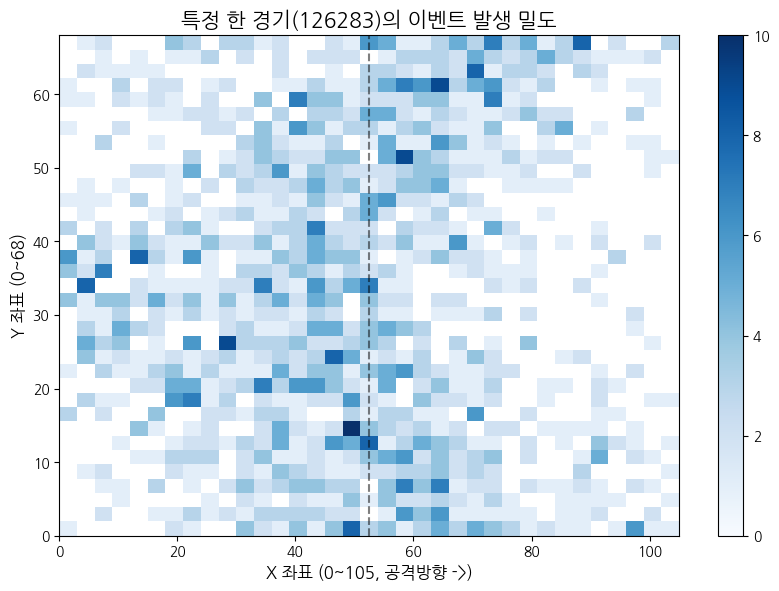

In [10]:
# 가장 첫 번째 경기(game_id) 찾기
first_game_id = train_df['game_id'].unique()[0]

# 첫 번째 경기 데이터만 필터링
single_match_df = train_df[train_df['game_id'] == first_game_id]

# 한 경기 전용 히트맵 그리기
plt.figure(figsize=(10, 6.5))
sns.histplot(x='start_x', y='start_y', data=single_match_df, bins=35, cmap='Blues', cbar=True)
plt.axvline(x=52.5, color='black', linestyle='--', alpha=0.5)

plt.title(f'특정 한 경기({first_game_id})의 이벤트 발생 밀도', fontsize=15)
plt.xlabel('X 좌표 (0~105, 공격방향 ->)', fontsize=12)
plt.ylabel('Y 좌표 (0~68)', fontsize=12)
plt.xlim(0, 105)
plt.ylim(0, 68)
plt.show()


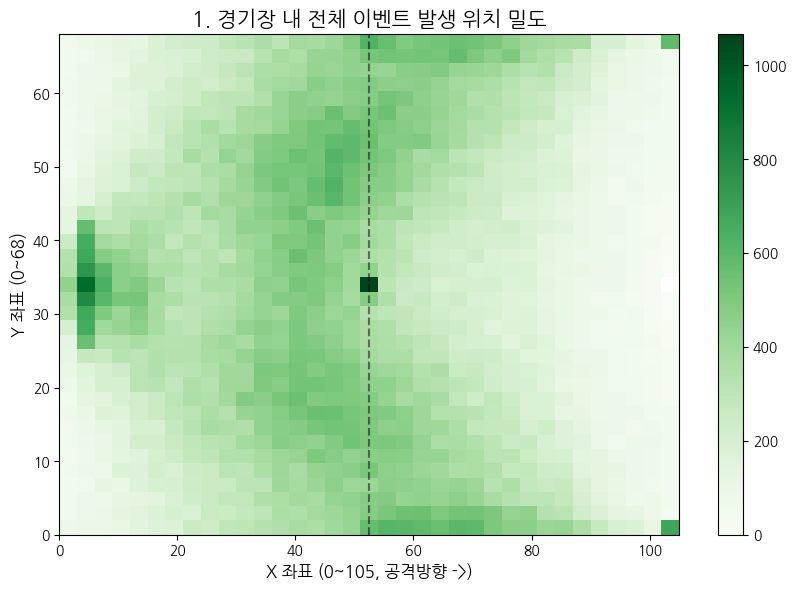

💡 인사이트: 이벤트가 경기장 중앙(X: 40~60) 부근과 양 측면 라인에 집중되어 있습니다. 현대 축구의 주된 빌드업이 중앙에서 이루어지며, 측면 전개가 빈번함을 의미합니다.


In [11]:
# 1. 시각화: 경기장 내 이벤트 발생 밀도 (Heatmap)
plt.figure(figsize=(10, 6.5))
sns.histplot(x='start_x', y='start_y', data=train_df, bins=35, cmap='Greens', cbar=True)
plt.axvline(x=52.5, color='black', linestyle='--', alpha=0.5) # 중앙선

plt.title('1. 경기장 내 전체 이벤트 발생 위치 밀도', fontsize=15)
plt.xlabel('X 좌표 (0~105, 공격방향 ->)', fontsize=12)
plt.ylabel('Y 좌표 (0~68)', fontsize=12)
plt.xlim(0, 105)
plt.ylim(0, 68)
plt.show()

print("💡 인사이트: 이벤트가 경기장 중앙(X: 40~60) 부근과 양 측면 라인에 집중되어 있습니다. 현대 축구의 주된 빌드업이 중앙에서 이루어지며, 측면 전개가 빈번함을 의미합니다.")

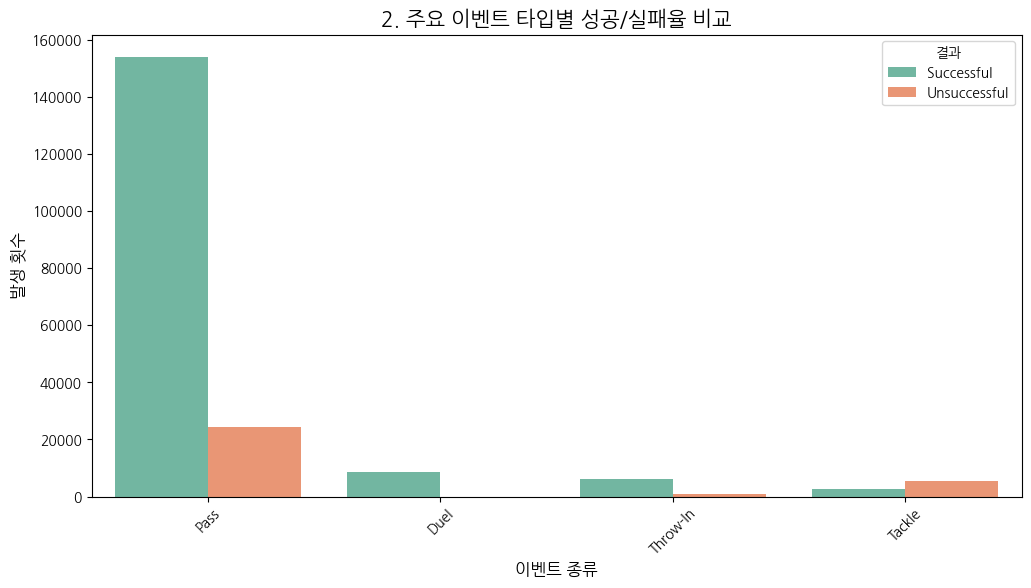

💡 인사이트: Pass는 압도적으로 성공률이 높지만, Cross나 Take-On(돌파)은 실패 비율이 높습니다. 좌표 예측 시 '이벤트의 종류'가 난이도를 결정짓는 핵심 변수입니다.


In [12]:
# 2. 시각화: 주요 이벤트 타입별 성공/실패 분포
plt.figure(figsize=(12, 6))

# 발생 빈도가 높은 상위 8개 이벤트 추출
top_events = train_df['type_name'].value_counts().nlargest(8).index
filtered_df = train_df[train_df['type_name'].isin(top_events)]

# 시각화 (결측치 제외)
sns.countplot(data=filtered_df.dropna(subset=['result_name']),
              x='type_name', hue='result_name', palette='Set2')

plt.title('2. 주요 이벤트 타입별 성공/실패율 비교', fontsize=15)
plt.xlabel('이벤트 종류', fontsize=12)
plt.ylabel('발생 횟수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='결과', loc='upper right')
plt.show()

print("💡 인사이트: Pass는 압도적으로 성공률이 높지만, Cross나 Take-On(돌파)은 실패 비율이 높습니다. 좌표 예측 시 '이벤트의 종류'가 난이도를 결정짓는 핵심 변수입니다.")

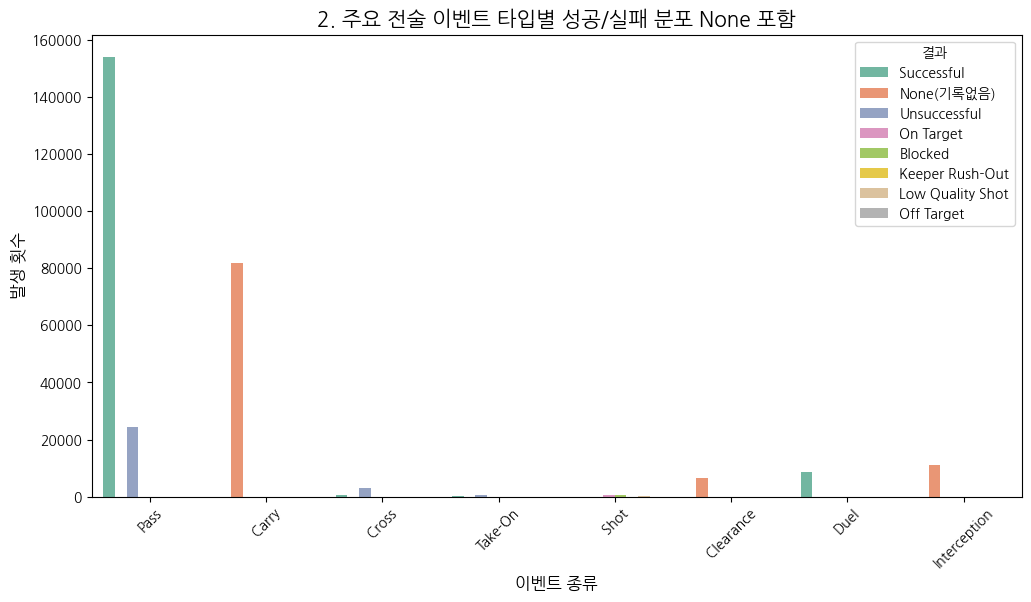

In [15]:
# 2. 시각화: 주요 핵심 이벤트 타입별 결과 분포
plt.figure(figsize=(12, 6))

# 상위 8개를
target_events = ['Pass', 'Carry', 'Cross', 'Take-On', 'Shot', 'Clearance', 'Duel', 'Interception']
filtered_df = train_df[train_df['type_name'].isin(target_events)].copy()

# Carry나 Clearance처럼 결과가 NaN인 것들을 지우지 않고 'None(기록없음)'으로 채워서 살리기
filtered_df['result_name'] = filtered_df['result_name'].fillna('None(기록없음)')

# 시각화
sns.countplot(data=filtered_df, x='type_name', hue='result_name', palette='Set2',
              order=target_events)

plt.title('2. 주요 전술 이벤트 타입별 성공/실패 분포 None 포함', fontsize=15)
plt.xlabel('이벤트 종류', fontsize=12)
plt.ylabel('발생 횟수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='결과', loc='upper right')
plt.show()



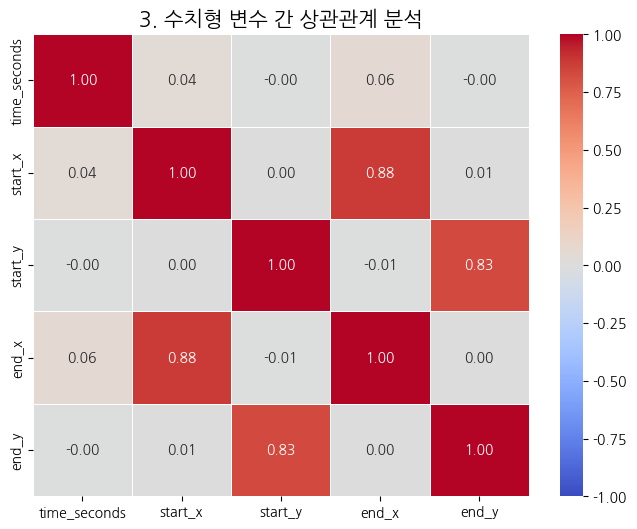

💡 인사이트: start_x와 end_x, start_y와 end_y 간에 강한 양(+)의 상관관계가 나타납니다. 즉, 대부분의 플레이가 비교적 짧은 거리 내에서 연속적으로 이동함을 의미합니다.


In [14]:
# 3. 시각화: 주요 수치형 변수 간 상관관계 (Heatmap)
plt.figure(figsize=(8, 6))

cols_to_corr = ['time_seconds', 'start_x', 'start_y', 'end_x', 'end_y']
corr_matrix = train_df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('3. 수치형 변수 간 상관관계 분석', fontsize=15)
plt.show()

print("💡 인사이트: start_x와 end_x, start_y와 end_y 간에 강한 양(+)의 상관관계가 나타납니다. 즉, 대부분의 플레이가 비교적 짧은 거리 내에서 연속적으로 이동함을 의미합니다.")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10145 (\N{BLACK RIGHTWARDS ARROW}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11013 (\N{LEFTWARDS BLACK ARROW}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


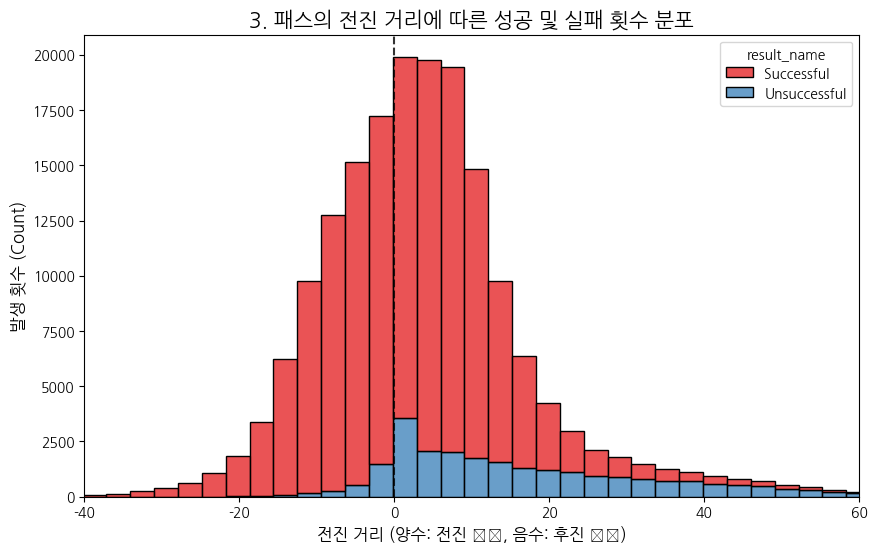

In [19]:
# 3. 시각화: 패스의 '전진 거리'에 따른 성공/실패 횟수 분포
pass_df = train_df[train_df['type_name'] == 'Pass'].copy()

# 전진 거리(X축 이동 거리) 계산
pass_df['forward_distance'] = pass_df['end_x'] - pass_df['start_x']

plt.figure(figsize=(10, 6))

sns.histplot(data=pass_df.dropna(subset=['result_name']),
             x='forward_distance', hue='result_name',
             bins=50, multiple="stack", palette='Set1')

plt.axvline(0, color='black', linestyle='--', alpha=0.8) # 전진/백패스 기준선

plt.title('3. 패스의 전진 거리에 따른 성공 및 실패 횟수 분포', fontsize=15)
plt.xlabel('전진 거리 (양수: 전진패스, 음수: 백패스 )', fontsize=12)
plt.ylabel('발생 횟수 (Count)', fontsize=12)
plt.xlim(-40, 60)
plt.show()